# Matplotlib for Engineering Students

### Session flow (2h 30m)
1. Why visualise data? Setup and imports
2. The Matplotlib object model: Figure, Axes, Axis, Artist
3. Line plots and customisation
4. Main plot types: scatter, bar, histogram, box plot, pie
5. Subplots and combining chart types
6. Working with real, date-indexed data
7. Styles, colormaps and saving figures
8. Misleading charts and how to avoid them
9. Practice - Core tasks
10. Quick Revision

> **Learning approach:** Read the definition → run the example → change the values → observe the output → complete the practice task.

**Dataset used:** `web_traffic_daily.csv` - one year of daily app/website metrics (visits, signups, page-load time, errors, deployment flags), including a real-looking incident.

# 1. Why Visualise Data?

Numbers in a table are hard to reason about at scale. A plot lets you see:
- Trends over time
- Comparisons across categories
- Relationships between variables
- Outliers and anomalies

For engineers, this matters directly: reading a sensor log, a server dashboard, or a lab result as a chart is almost always faster and more reliable than scanning rows of numbers.

### Setup

In [14]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

print("Matplotlib version:", mpl.__version__)
print("Pandas version:", pd.__version__)

%matplotlib inline

Matplotlib version: 3.11.2
Pandas version: 3.0.6


# 2. The Matplotlib Object Model

### Definition

Matplotlib has two ways of plotting:

- **pyplot interface** (`plt.plot(...)`) - quick, implicit, good for one-off scripts.
- **Object-oriented (OO) interface** - you explicitly create a `Figure` and one or more `Axes`, then call methods on them.

**We will use the OO interface as the standard** for this course, because it scales cleanly to subplots, is easier to debug, and matches how Matplotlib is used in real codebases.

Key objects:

| Object | What it is |
|---|---|
| `Figure` | The whole canvas/window - can hold one or more Axes |
| `Axes` | A single plot area (has x-axis, y-axis, title, data) - **not** the same as "axis" |
| `Axis` | One axis (x or y) of an Axes - controls ticks, limits, scale |
| `Artist` | Everything drawn: lines, text, ticks, legends |

```python
fig, ax = plt.subplots()      # 1 Figure containing 1 Axes
ax.plot(x, y)                 # draw on that Axes
ax.set_title("...")
plt.show()
```

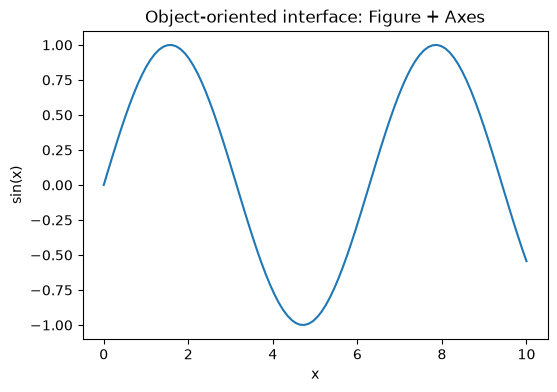

Type of fig: <class 'matplotlib.figure.Figure'>
Type of ax: <class 'matplotlib.axes._axes.Axes'>


In [15]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y)
ax.set_title("Object-oriented interface: Figure + Axes")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
plt.show()

print("Type of fig:", type(fig))
print("Type of ax:", type(ax))

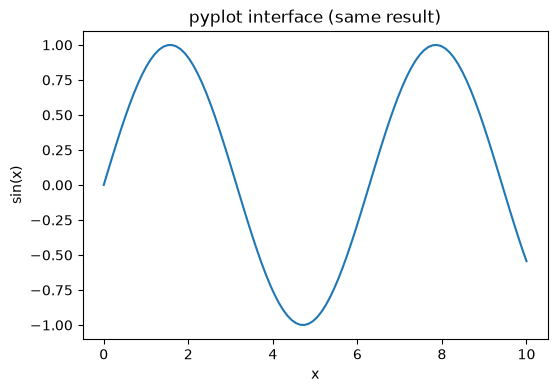

In [16]:
# pyplot (implicit) interface -- same plot, different style of writing it
plt.figure(figsize=(6, 4))
plt.plot(x, y)
plt.title("pyplot interface (same result)")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.show()

# Try this: change np.sin(x) to np.cos(x) above and re-run both cells.
# Notice the OO version is easier to extend -- e.g. add a second line with ax.plot(...) again.

# 3. Line Plots and Customisation

### Definition

`ax.plot()` draws a line plot. Common customisations:

| Parameter | Meaning |
|---|---|
| `color` | line colour (name, hex, or shorthand like `"r"`) |
| `linestyle` | `"-"`, `"--"`, `"-."`, `":"` |
| `linewidth` | thickness |
| `marker` | point marker: `"o"`, `"s"`, `"^"`, `"x"` |
| `label` | name used in the legend |

Other Axes methods you'll use constantly: `set_title`, `set_xlabel`, `set_ylabel`, `legend`, `grid`, `set_xlim` / `set_ylim`, `set_xticks`, `set_yscale`.

In [17]:
df = pd.read_csv("./web_traffic_daily.csv", parse_dates=["date"])
df.head()
df["date"] = pd.to_datetime(df["date"],format="%d-%m-%Y")

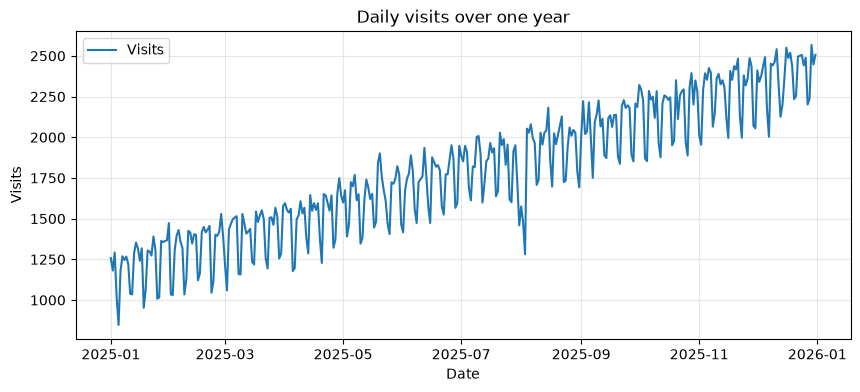

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df["date"], df["visits"], color="tab:blue", linewidth=1.5, label="Visits")
ax.set_title("Daily visits over one year")
ax.set_xlabel("Date")
ax.set_ylabel("Visits")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# Try this:
# 1. Add a second line for df["signups"] on the same Axes.
# 2. Change linestyle to "--" for one of the two lines.
# 3. Use ax.set_yscale("log") and observe what changes.

# 4. Main Plot Types

### Definition

| Chart | Use it to show | Call |
|---|---|---|
| Scatter | Relationship between two numeric variables | `ax.scatter(x, y)` |
| Bar | Comparison across categories | `ax.bar(x, height)` |
| Histogram | Distribution of one numeric variable | `ax.hist(data, bins=...)` |
| Box plot | Spread, median, outliers | `ax.boxplot(data)` |
| Pie | Share of a whole (use sparingly - see section 8) | `ax.pie(sizes)` |

### 4.1 Scatter plot

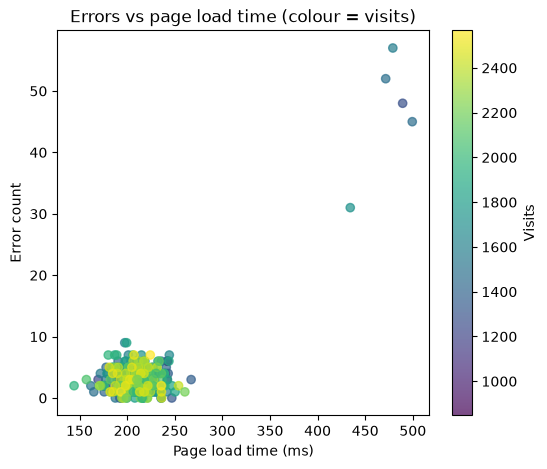

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df["page_load_ms"], df["error_count"],
                 c=df["visits"], cmap="viridis", alpha=0.7)
ax.set_title("Errors vs page load time (colour = visits)")
ax.set_xlabel("Page load time (ms)")
ax.set_ylabel("Error count")
fig.colorbar(sc, ax=ax, label="Visits")
plt.show()

# Try this: change c=df["visits"] to c=df["deployment_flag"] and pick a 2-colour cmap.

### 4.2 Bar chart - grouped and stacked

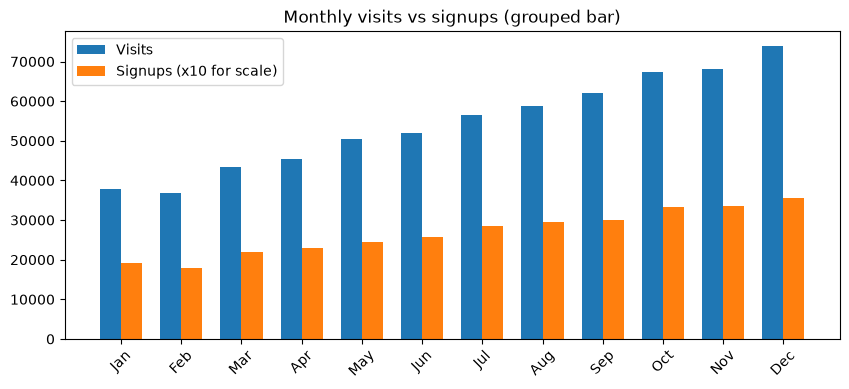

In [20]:
monthly = df.set_index("date").resample("ME")[["visits", "signups"]].sum()
monthly.index = monthly.index.strftime("%b")

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(monthly))
width = 0.35

ax.bar(x - width/2, monthly["visits"], width, label="Visits")
ax.bar(x + width/2, monthly["signups"] * 10, width, label="Signups (x10 for scale)")
ax.set_xticks(x)
ax.set_xticklabels(monthly.index, rotation=45)
ax.set_title("Monthly visits vs signups (grouped bar)")
ax.legend() 
plt.show()

# Try this: make it a STACKED bar instead of grouped by using
# ax.bar(x, visits) then ax.bar(x, signups, bottom=visits)

### 4.3 Histogram

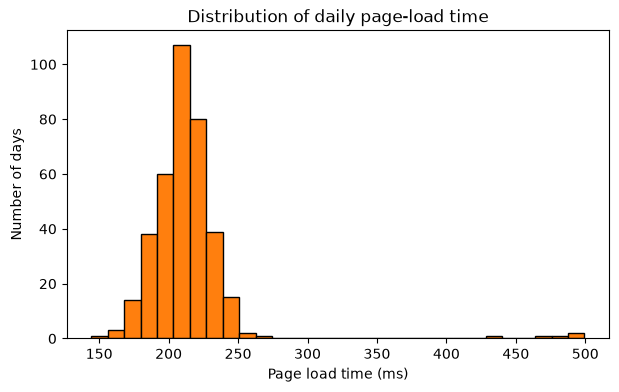

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["page_load_ms"], bins=30, color="tab:orange", edgecolor="black")
ax.set_title("Distribution of daily page-load time")
ax.set_xlabel("Page load time (ms)")
ax.set_ylabel("Number of days")
plt.show()

# Try this: change bins to 10 and then to 60. What changes about how
# well you can "read" the distribution?

### 4.4 Box plot

/tmp/ipykernel_275778/594888198.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df["error_count"], vert=True, patch_artist=True,


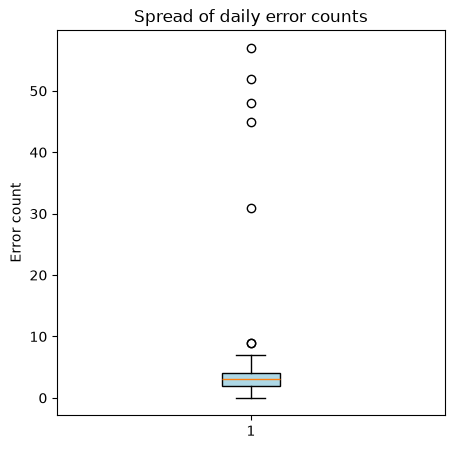

Any point beyond the whiskers is considered a potential outlier.


In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.boxplot(df["error_count"], vert=True, patch_artist=True,
           boxprops=dict(facecolor="lightblue"))
ax.set_title("Spread of daily error counts")
ax.set_ylabel("Error count")
plt.show()

print("Any point beyond the whiskers is considered a potential outlier.")

### 4.5 Pie chart (use with caution)

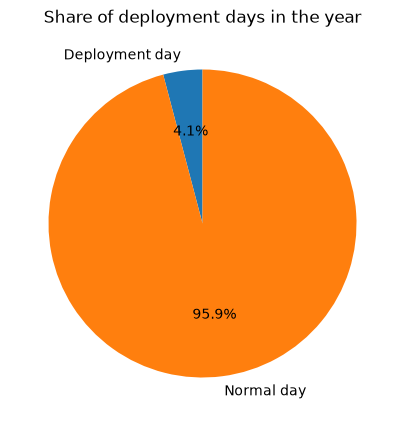

In [23]:
deploy_days = df["deployment_flag"].sum()
normal_days = len(df) - deploy_days

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([deploy_days, normal_days],
       labels=["Deployment day", "Normal day"],
       autopct="%1.1f%%", startangle=90)
ax.set_title("Share of deployment days in the year")
plt.show()

# Pie charts work only when there are FEW categories and the reader needs
# "share of a whole", not precise comparison. A bar chart is usually clearer
# once you have more than 3-4 slices.

# 5. Subplots

### Definition

`plt.subplots(nrows, ncols)` returns a Figure and an array of Axes, letting you place several related plots in a grid.

Useful options: `figsize`, `sharex`, `sharey`, `constrained_layout=True` (avoids overlapping labels).

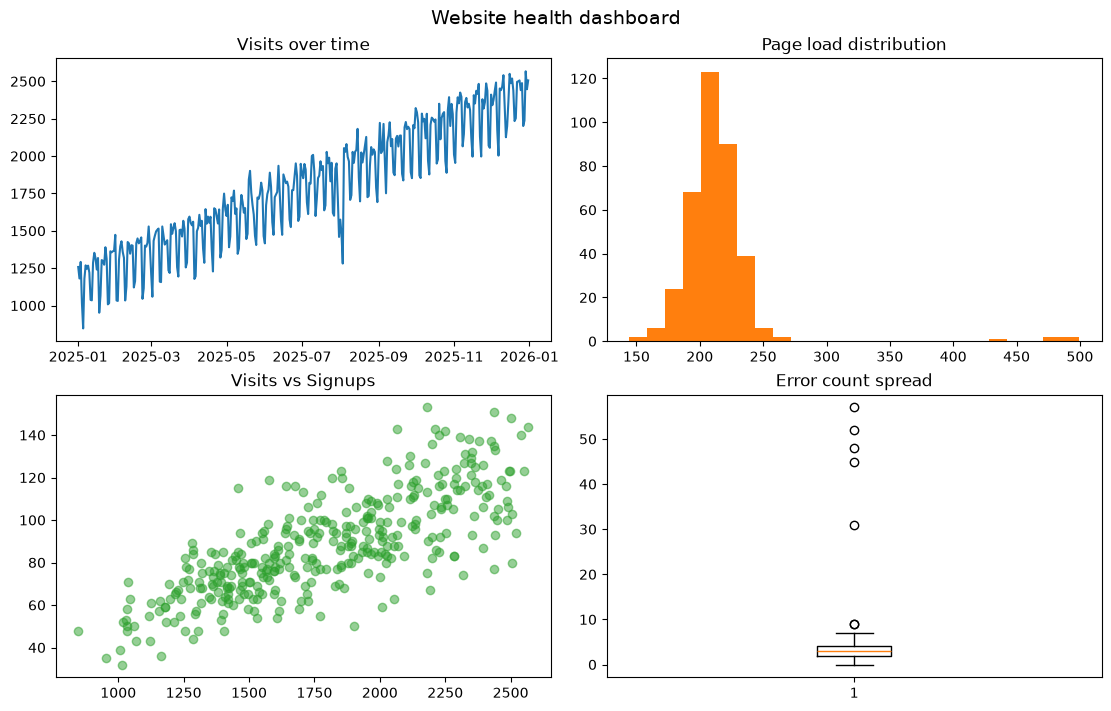

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

axes[0, 0].plot(df["date"], df["visits"], color="tab:blue")
axes[0, 0].set_title("Visits over time")

axes[0, 1].hist(df["page_load_ms"], bins=25, color="tab:orange")
axes[0, 1].set_title("Page load distribution")

axes[1, 0].scatter(df["visits"], df["signups"], alpha=0.5, color="tab:green")
axes[1, 0].set_title("Visits vs Signups")

axes[1, 1].boxplot(df["error_count"])
axes[1, 1].set_title("Error count spread")

fig.suptitle("Website health dashboard", fontsize=14)
plt.show()

# Try this: change to plt.subplots(1, 4, figsize=(18, 4)) and index axes as axes[0], axes[1], ...

# 6. Working With Real, Date-Indexed Data

### Definition

Common needs when plotting time series:
- Dates directly on the x-axis (Matplotlib understands `datetime64` columns)
- A rolling/moving average to smooth noise
- Marking an event with `ax.axvline()`
- Shading a region with `ax.fill_between()`
- Two different y-scales sharing one x-axis with `ax.twinx()`

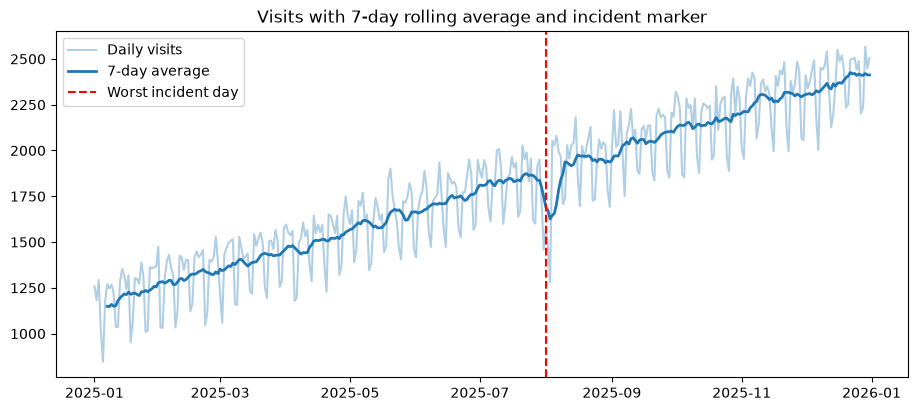

In [25]:
df["visits_7d_avg"] = df["visits"].rolling(7).mean()
incident_date = df.loc[df["error_count"].idxmax(), "date"]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df["date"], df["visits"], alpha=0.35, label="Daily visits")
ax.plot(df["date"], df["visits_7d_avg"], color="tab:blue", linewidth=2, label="7-day average")
ax.axvline(incident_date, color="red", linestyle="--", label="Worst incident day")
ax.set_title("Visits with 7-day rolling average and incident marker")
ax.legend()
plt.show()

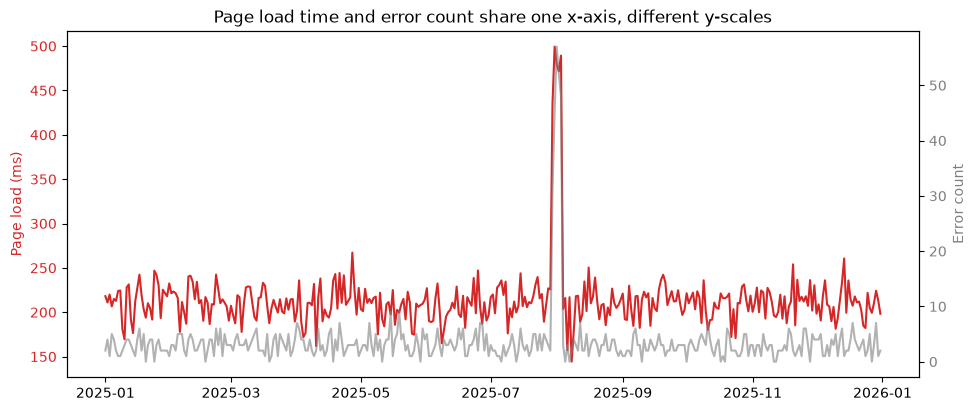

In [26]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))

ax1.plot(df["date"], df["page_load_ms"], color="tab:red")
ax1.set_ylabel("Page load (ms)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(df["date"], df["error_count"], color="tab:gray", alpha=0.6)
ax2.set_ylabel("Error count", color="tab:gray")
ax2.tick_params(axis="y", labelcolor="tab:gray")

ax1.set_title("Page load time and error count share one x-axis, different y-scales")
plt.show()

# twinx() is the standard way to compare two metrics with very different
# units/scales on the same timeline.

# 7. Styles, Colormaps and Saving Figures

### Definition

- `plt.style.use("seaborn-v0_8")` (or another built-in style) changes the overall look in one line.
- Colormaps (`cmap=`) control colour for continuous data - `"viridis"`, `"plasma"`, and `"coolwarm"` are colour-blind-friendlier choices than `"jet"`.
- `fig.savefig()` exports a figure. Important arguments:
  - `dpi=300` for print/report quality
  - `bbox_inches="tight"` to avoid clipped labels
  - format is inferred from the extension: `.png`, `.svg`, `.pdf`

Available styles (sample): ['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale']


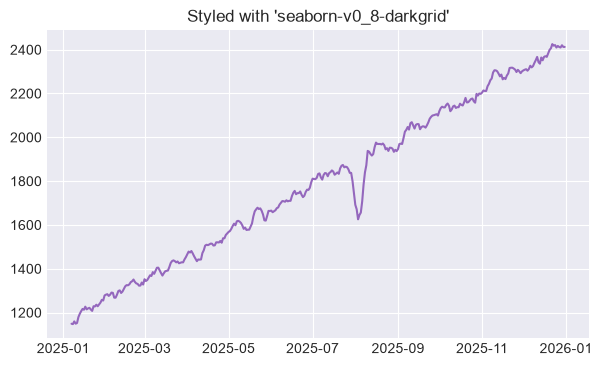

In [27]:
print("Available styles (sample):", plt.style.available[:8])

with plt.style.context("seaborn-v0_8-darkgrid"):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(df["date"], df["visits_7d_avg"], color="tab:purple")
    ax.set_title("Styled with 'seaborn-v0_8-darkgrid'")
    plt.show()

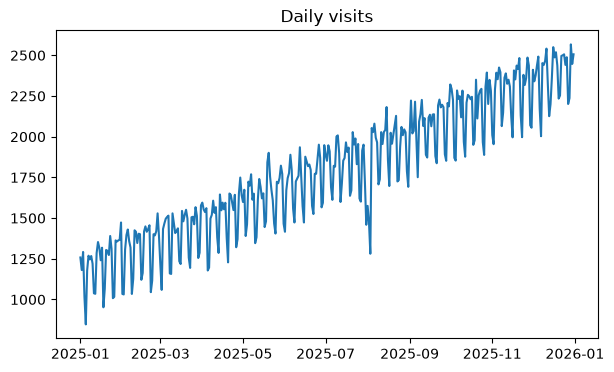

Saved visits_plot.png in the current working directory.


In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["date"], df["visits"], color="tab:blue")
ax.set_title("Daily visits")
fig.savefig("visits_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved visits_plot.png in the current working directory.")
# Try this: also save as "visits_plot.svg" and compare file sizes.

# 8. Misleading Charts - What to Avoid

A chart can be technically correct and still misleading. Common problems:

- **Truncated y-axis** - starting bars at a value other than 0 exaggerates differences.
- **Too many pie slices** - beyond 4–5 categories, a pie chart becomes unreadable; use a bar chart.
- **Unlabelled axes** - a chart without units or a title forces the reader to guess.
- **Dual y-axes without care** - two lines that *look* like they cross meaningfully but are on unrelated scales.
- **Overplotting** - thousands of overlapping points hide the real density; reduce with `alpha`, or use a 2D histogram / hexbin instead.

### Chart-selection quick guide

| Question you're asking | Chart |
|---|---|
| How does this change over time? | Line plot |
| How do groups compare? | Bar plot |
| What does the distribution look like? | Histogram / box plot |
| Is there a relationship between two numeric variables? | Scatter plot |
| What's the share of a whole (few categories)? | Pie / stacked bar |

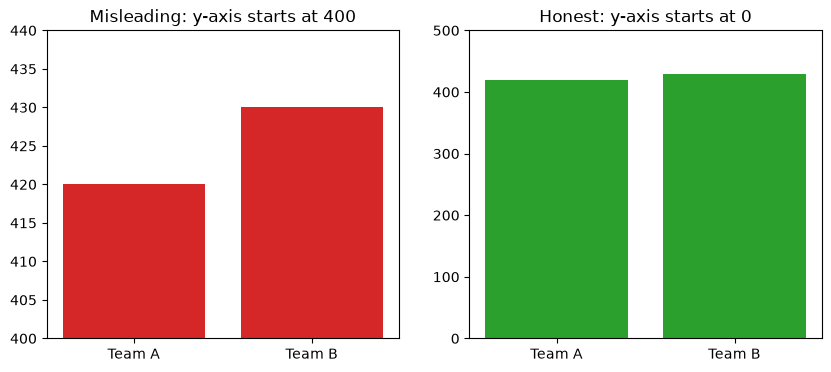

In [29]:
# Demonstration: truncated axis exaggerates a small difference
values = [420, 430]
labels = ["Team A", "Team B"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, values, color="tab:red")
axes[0].set_ylim(400, 440)
axes[0].set_title("Misleading: y-axis starts at 400")

axes[1].bar(labels, values, color="tab:green")
axes[1].set_ylim(0, 500)
axes[1].set_title("Honest: y-axis starts at 0")

plt.show()

# Both charts show the SAME two numbers. Only the axis range changed.
# Spot the difference in how "big" the gap looks.

# 9. Practice - Apply the Core Concepts

Use `data/web_traffic_daily.csv` for all tasks unless stated otherwise.

### Beginner
1. Plot `signups` over time as a line chart with a title, axis labels, and grid.
2. Create a histogram of `error_count` with 20 bins.
3. Create a bar chart comparing total `visits` for each month.

### AI/ML & engineering-focused
4. Create a figure with 2 subplots side by side: (a) a scatter of `visits` vs `signups`, (b) a box plot of `page_load_ms`.
5. Plot `page_load_ms` over time, add a `7-day rolling average` line, and mark the day with the highest `error_count` using `axvline`.
6. Recreate the "misleading vs honest" bar chart demonstration using two categories and numbers of your own choice.
7. Save any one of your figures as a 300-dpi PNG with `bbox_inches="tight"`.

Write your code in the cells below.

In [30]:
# Task 1

In [31]:
# Task 2

In [32]:
# Task 3

In [33]:
# Task 4

In [34]:
# Task 5

In [35]:
# Task 6

In [36]:
# Task 7

# Quick Revision - Matplotlib

- **Object model:** `Figure` (canvas) → `Axes` (a plot) → `Axis` (x or y) → `Artist` (everything drawn). Prefer the OO interface: `fig, ax = plt.subplots()`.
- **Line plot:** `ax.plot(x, y, color=, linestyle=, marker=, label=)`
- **Scatter:** `ax.scatter(x, y, c=, cmap=, alpha=)` - for relationships between two numeric variables
- **Bar:** `ax.bar(x, height)` - grouped with an offset, stacked with `bottom=`
- **Histogram:** `ax.hist(data, bins=)` - for distributions
- **Box plot:** `ax.boxplot(data)` - median, IQR, outliers
- **Subplots:** `fig, axes = plt.subplots(nrows, ncols, figsize=, constrained_layout=True)`
- **Time series helpers:** `.rolling(n).mean()`, `ax.axvline()`, `ax.fill_between()`, `ax.twinx()`
- **Styling:** `plt.style.use(...)`, colour-blind-friendly cmaps (`viridis`, `coolwarm`)
- **Saving:** `fig.savefig("name.png", dpi=300, bbox_inches="tight")`
- **Beware:** truncated axes, too many pie slices, missing labels, overplotting